In [4]:
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# LOAD — the raw export has a known quirk: the header row has 15 column names
# but every data row has 16 fields (a trailing per-opportunity row-counter with
# no header). Default read_csv silently uses column 0 as the index to absorb
# the mismatch, which shifts EVERY column over by one. index_col=False forces
# pandas to keep the header alignment and drop the extra unnamed trailing field
# instead (which we don't need for reporting).
# ─────────────────────────────────────────────────────────────────────────────
placementhistory = pd.read_csv('CareerLaunch2026PlacementHistory.csv', index_col=False)

print("=== Shape & columns ===")
print(placementhistory.shape)
print(placementhistory.columns.tolist())

print("\n=== Dtypes (raw) ===")
print(placementhistory.dtypes)

# Clean up types
placementhistory['Changed Date'] = pd.to_datetime(placementhistory['Changed Date'], format='%m/%d/%Y')
placementhistory['Student Code'] = placementhistory['Student Code'].astype('Int64')  # nullable int, drops the ".0"

print("\n=== Opportunity Status value counts ===")
print(placementhistory['Opportunity Status'].value_counts())

print("\n=== Hub ('Group Name') value counts ===")
print(placementhistory['Group Name'].value_counts())

print("\n=== Placement Status value counts (raw log rows, NOT deduped) ===")
print(placementhistory['Placement Status'].value_counts())

print("\n=== Date range covered ===")
print(placementhistory['Changed Date'].min(), '->', placementhistory['Changed Date'].max())

print("\n=== Daily change volume (helps spot bulk-match days) ===")
print(placementhistory['Changed Date'].value_counts().sort_index())

# ─────────────────────────────────────────────────────────────────────────────
# This file is a STATUS LOG, not one row per placement. Many Opportunity /
# Student pairs show up multiple times as their status changes over time
# (e.g. Offered -> Confirmed, or Offered -> Rejected).
# ─────────────────────────────────────────────────────────────────────────────
matched = placementhistory.dropna(subset=['Student Code']).copy()
dupe_counts = matched.groupby(['Opportunity Id', 'Student Code']).size()
print(f"\n{(dupe_counts > 1).sum()} of {len(dupe_counts)} opportunity-student pairs have more than one log row")

# Take the LATEST status per opportunity-student pair (sort by date, keep last)
matched_sorted = matched.sort_values(['Opportunity Id', 'Student Code', 'Changed Date', 'Changed Time'])
latest_status = matched_sorted.groupby(['Opportunity Id', 'Student Code']).tail(1).copy()

print(f"\n=== Deduped to {len(latest_status)} unique opportunity-student final records ===")
print(latest_status['Placement Status'].value_counts())

# ─────────────────────────────────────────────────────────────────────────────
# CORE MATCHING FUNNEL (final status only)
# ─────────────────────────────────────────────────────────────────────────────
print("\n=== Final status by hub ===")
funnel = latest_status.groupby(['Group Name', 'Placement Status']).size().unstack(fill_value=0)
print(funnel)

confirmed = latest_status[latest_status['Placement Status'] == 'Confirmed']
print(f"\nTotal CONFIRMED placements: {len(confirmed)}")
print(f"Unique students confirmed: {confirmed['Student Code'].nunique()}")
print(f"Unique agencies matched:   {confirmed['Agency Id'].nunique()}")

print("\n=== Confirmed matches & unique agencies by hub ===")
by_hub = confirmed.groupby('Group Name').agg(
    students_matched=('Student Code', 'nunique'),
    agencies_matched=('Agency Id', 'nunique'),
    opportunities_used=('Opportunity Id', 'nunique'),
)
print(by_hub)

# ─────────────────────────────────────────────────────────────────────────────
# MATCH TYPE — this cycle had TWO bulk rounds, unlike last cycle's single
# admin-run bulk push. Round 1 (6/4-6/11) was run by the admin account
# (elijahnunez@gmail.com), same as last cycle. Round 2 (7/1-7/2) was a second,
# hub-coordinator-led batch push -- run by Allison.Griffin and Jaquelyn Abo
# Trabi Al Awar, each processing their whole batch in a single day. Per Juan:
# treat Round 2 as "Bulk Rematching" -- its own round, but still bulk-style.
#
# Pre-Match: confirmed before Round 1 ramped up (mirrors last cycle's
# pre-February-2 pre-match window, just a different cutoff date this cycle).
# Manual Match: everything else -- low-volume individual/coordinator activity
# between or after the two bulk rounds.
# ─────────────────────────────────────────────────────────────────────────────
PRE_MATCH_CUTOFF = pd.Timestamp('2026-06-03')     # last date before Round 1 ramp-up
ROUND1_START, ROUND1_END = pd.Timestamp('2026-06-04'), pd.Timestamp('2026-06-11')
ROUND2_START, ROUND2_END = pd.Timestamp('2026-07-01'), pd.Timestamp('2026-07-02')

ROUND1_BULK_ACCOUNTS = ['elijahnunez@gmail.com']
ROUND2_BULK_ACCOUNTS = ['Allison.Griffin', '23053377']  # Jaquelyn Abo Trabi Al Awar's ID

print("\n=== Created By value counts, top 15 (staff/bulk accounts vs. student/coordinator IDs) ===")
print(confirmed['Created By'].value_counts().head(15))


def classify_match_type(row):
    created_by = row['Created By']
    date = row['Changed Date']

    is_round1_bulk_acct = any(acct in created_by for acct in ROUND1_BULK_ACCOUNTS)
    is_round2_bulk_acct = any(acct in created_by for acct in ROUND2_BULK_ACCOUNTS)

    if is_round1_bulk_acct and ROUND1_START <= date <= ROUND1_END:
        return 'Bulk Match'
    if is_round2_bulk_acct and ROUND2_START <= date <= ROUND2_END:
        return 'Bulk Rematching'
    if date <= PRE_MATCH_CUTOFF:
        return 'Pre-Match'
    return 'Manual Match'


confirmed['match_type'] = confirmed.apply(classify_match_type, axis=1)

print("\n=== Match type totals (overall) ===")
print(confirmed['match_type'].value_counts())

print("\n=== Match type by hub ===")
match_type_by_hub = confirmed.groupby(['Group Name', 'match_type']).size().unstack(fill_value=0)
print(match_type_by_hub)

print("\n=== Final summary table (mirrors last cycle's report format) ===")
summary = confirmed.groupby('Group Name').agg(
    Unique_Students_Matched=('Student Code', 'nunique'),
    Unique_Agencies_Matched=('Agency Id', 'nunique'),
).join(
    confirmed.pivot_table(index='Group Name', columns='match_type', values='Student Code',
                           aggfunc='nunique', fill_value=0)
)
print(summary)
print(f"\nTotal Unique Agencies Matched (all hubs): {confirmed['Agency Id'].nunique()}")

# ─────────────────────────────────────────────────────────────────────────────
# CAPACITY UTILIZATION — how full did opportunities get vs. their Min/Max Places?
# ─────────────────────────────────────────────────────────────────────────────
print("\n=== Capacity check ===")
opp_capacity = placementhistory[['Opportunity Id', 'Min Places', 'Max Places']].drop_duplicates('Opportunity Id')
opp_capacity['Max Places'] = pd.to_numeric(opp_capacity['Max Places'], errors='coerce')
filled = confirmed.groupby('Opportunity Id').size().rename('Filled')
capacity = opp_capacity.set_index('Opportunity Id').join(filled).fillna({'Filled': 0})
print(capacity.describe())

# ─────────────────────────────────────────────────────────────────────────────
# GEOGRAPHY — sanity check before mapping
# ─────────────────────────────────────────────────────────────────────────────
print("\n=== Missing lat/lon among confirmed placements ===")
print(confirmed[['Postal Address Latitude', 'Postal Address Longitude']].isna().sum())

=== Shape & columns ===
(3043, 15)
['Opportunity Id', 'Opportunity Name', 'Opportunity Status', 'Group Name', 'Min Places', 'Max Places', 'Agency Id', 'Agency Name', 'Postal Address Latitude', 'Postal Address Longitude', 'Student Code', 'Changed Date', 'Created By', 'Placement Status', 'Changed Time']

=== Dtypes (raw) ===
Opportunity Id               object
Opportunity Name             object
Opportunity Status           object
Group Name                   object
Min Places                    int64
Max Places                    int64
Agency Id                    object
Agency Name                  object
Postal Address Latitude     float64
Postal Address Longitude    float64
Student Code                float64
Changed Date                 object
Created By                   object
Placement Status             object
Changed Time                 object
dtype: object

=== Opportunity Status value counts ===
Opportunity Status
Published    2984
Draft          39
Archived       20
Name: c

/var/folders/8k/0h5dy3dn6wl02x9lkdb7xk0m0000gn/T/ipykernel_32684/1153201795.py:11: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  placementhistory = pd.read_csv('CareerLaunch2026PlacementHistory.csv', index_col=False)
/var/folders/8k/0h5dy3dn6wl02x9lkdb7xk0m0000gn/T/ipykernel_32684/1153201795.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  confirmed['match_type'] = confirmed.apply(classify_match_type, axis=1)


## OLD 

In [6]:
df_2 = pd.read_excel('PlacementHistory.xlsx')
df_2. columns.to_list

<bound method IndexOpsMixin.tolist of Index(['Opportunity Id', 'Opportunity Name', 'Opportunity Status',
       'Group Name', 'Min Places', 'Max Places', 'Agency Id', 'Agency Name',
       'Postal Address Latitude', 'Postal Address Longitude', 'Student Code',
       'Changed Date', 'Created By', 'Placement Status', 'Changed Time'],
      dtype='object')>

In [58]:
Total_Student_matches = df_2.groupby('Group Name')['Student Code'].nunique()
Total_agencies_matched = df_2.groupby('Group Name')['Agency Id'].nunique()
Total_Uagencies_matched = df_2['Agency Id'].nunique()

bulk_matches = df_2[df_2["Created By"] == "elijahnunez@gmail.com"].groupby('Group Name')['Student Code'].nunique()

pre_matches = df_2[
    (df_2["Created By"] != "elijahnunez@gmail.com") & 
    (df_2["Changed Date"] <= "2026-02-02") &
    (df_2["Changed Date"].notna()) 
].groupby('Group Name')['Student Code'].nunique()

manual_matches = df_2[
    (df_2["Created By"] != "elijahnunez@gmail.com") & 
    (df_2["Changed Date"] >= "2026-02-03") & 
    (df_2["Changed Date"] <= "2026-02-06")
].groupby('Group Name')['Student Code'].nunique()

summary = pd.DataFrame({
    'Unique Students Matched': Total_Student_matches,
    'Unique Agencies Matched': Total_agencies_matched,
    'Accepted Pre Matches':     pre_matches,
    'Accepted Bulk Matches':    bulk_matches,
    'Accepted Manual Matches':  manual_matches,
}).fillna(0).astype(int)

print(summary.to_string())
print(f"Total Unique Agencies Matched: {Total_Uagencies_matched}")


                                                     Unique Students Matched  Unique Agencies Matched  Accepted Pre Matches  Accepted Bulk Matches  Accepted Manual Matches
Group Name                                                                                                                                                                 
2026 Spring Forward - Community and Social Services                      218                       98                    61                     74                       69
2026 Spring Forward - Healthcare                                         228                       68                    42                    146                       54
2026 Spring Forward - Marketing and Communications                       244                       98                     7                    212                       14
2026 Spring Forward - STEM and Green                                     243                       64                    37                 

In [34]:
df = pd.read_excel('SF26StudentOpportunityApplications.xlsx')
df.head()


,Opportunity Application Id,Agency Id,Opportunity Application Comments,Opportunity Id,Student Code,StudentPreference,Coordinator Preference Rank,Opportunity Application Status,Opportunity Application Created Date,Opportunity Application Status _update Date,Opportunity Application Status _update User,Opportunity Campaign Name,Student Name,Student Status,Unnamed: 14
0,67b8c9e1-2731-4d37-7ae9-08de3f3782be,149fb918-5017-f011-81a3-90cb95efafa1,NaN,c8efcdaa-ce5c-4cf6-7523-08de04de5ec8,12080666,0,11.0,Student Declined,2026-01-05 04:33:00,2026-02-03 14:04:00,elijahnunez@gmail.com,2026 Spring Forward - Community and Social Ser...,Riti Chavez,Enrolled,1
1,602b64d7-b9f5-4388-ae81-08de4ced310c,cda3b918-5017-f011-81a3-90cb95efafa1,NaN,6ffa3ba3-a873-44c8-0c4e-08ddffe8b865,12080666,0,1.0,Student Declined,2026-01-06 18:03:00,2026-02-03 14:04:00,elijahnunez@gmail.com,2026 Spring Forward - Community and Social Ser...,Riti Chavez,Enrolled,2
2,352239c8-900b-47e0-ae7d-08de4ced310c,e825ac36-4897-4f96-d6f4-08de109d25d3,NaN,9534e212-d844-4631-558d-08de118058ed,12080666,1,NaN,Student Declined,2026-01-06 18:01:00,2026-02-03 14:04:00,elijahnunez@gmail.com,2026 Spring Forward - Community and Social Ser...,Riti Chavez,Enrolled,3
3,88c64abd-96b3-49a3-aeaa-08de4ced310c,fe5944a4-4f70-4813-e458-08ddfc329806,NaN,03327062-5052-4159-0cbd-08ddffe8b865,12080666,2,NaN,Student Declined,2026-01-06 18:19:00,2026-02-03 14:04:00,elijahnunez@gmail.com,2026 Spring Forward - Community and Social Ser...,Riti Chavez,Enrolled,4
4,9b08bfda-2b19-4114-7ae8-08de3f3782be,05a2b918-5017-f011-81a3-90cb95efafa1,NaN,1efa3551-55f8-44e1-0ca3-08ddffe8b865,12080666,3,NaN,Placed,2026-01-05 04:31:00,2026-02-03 14:06:00,elijahnunez@gmail.com,2026 Spring Forward - Community and Social Ser...,Riti Chavez,Enrolled,5


In [ ]:
placed_df = df[df['Opportunity Application Status'] == 'Placed']

/var/folders/j5/xxl46v1947x3ydj0jpkl3_yc0000gq/T/ipykernel_44132/1799143206.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  placed_df['StudentPreference'] = pd.to_numeric(placed_df['StudentPreference'], errors='coerce').fillna(0).astype(int)
/var/folders/j5/xxl46v1947x3ydj0jpkl3_yc0000gq/T/ipykernel_44132/1799143206.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  placed_df['Coordinator Preference Rank'] = pd.to_numeric(placed_df['Coordinator Preference Rank'], errors='coerce').fillna(0).astype(int)


Saved: preference_histograms.png
Saved: preference_bubble.png


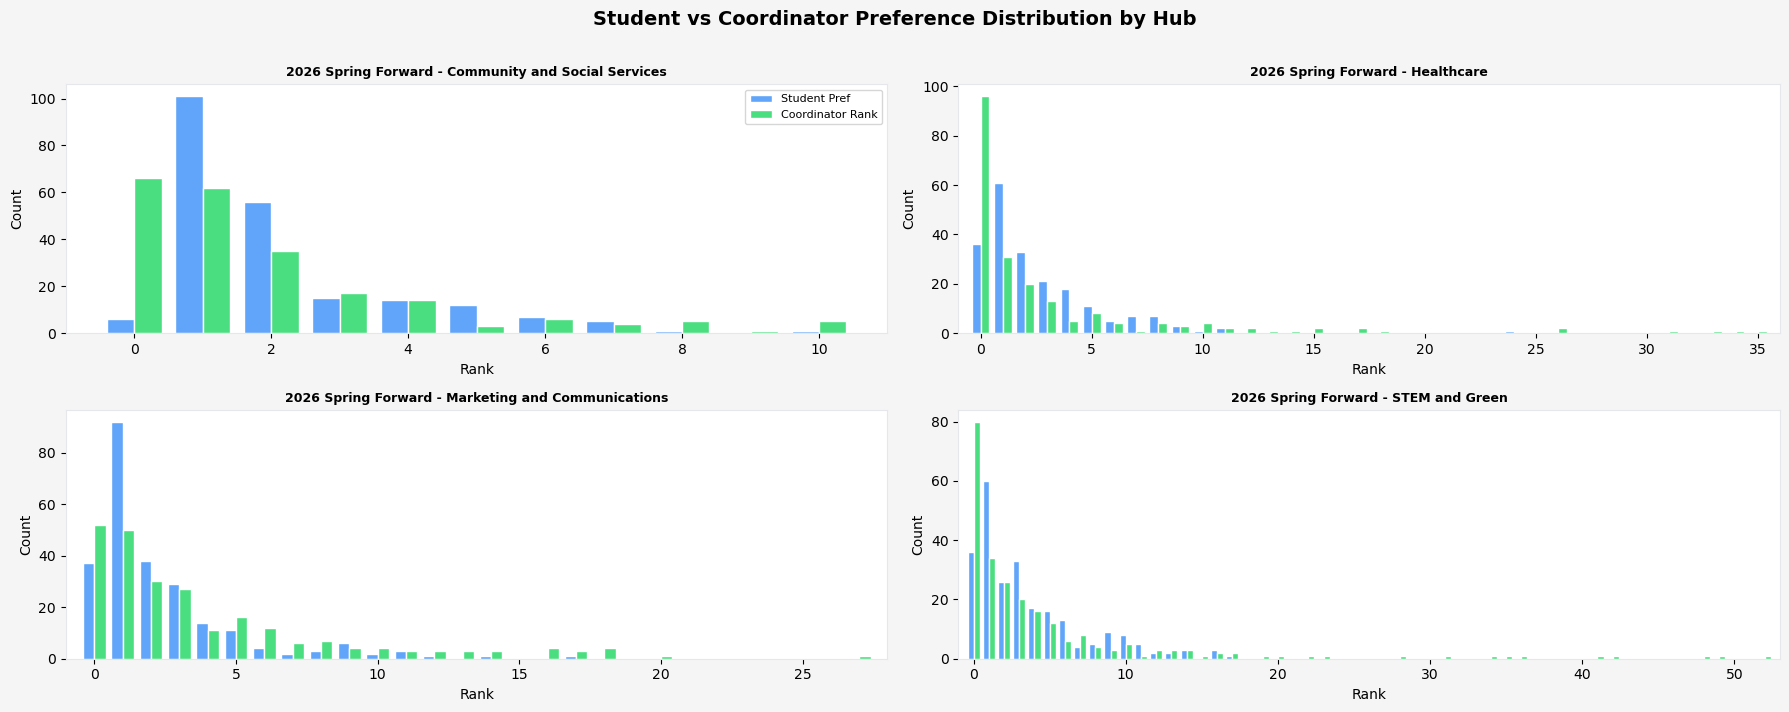

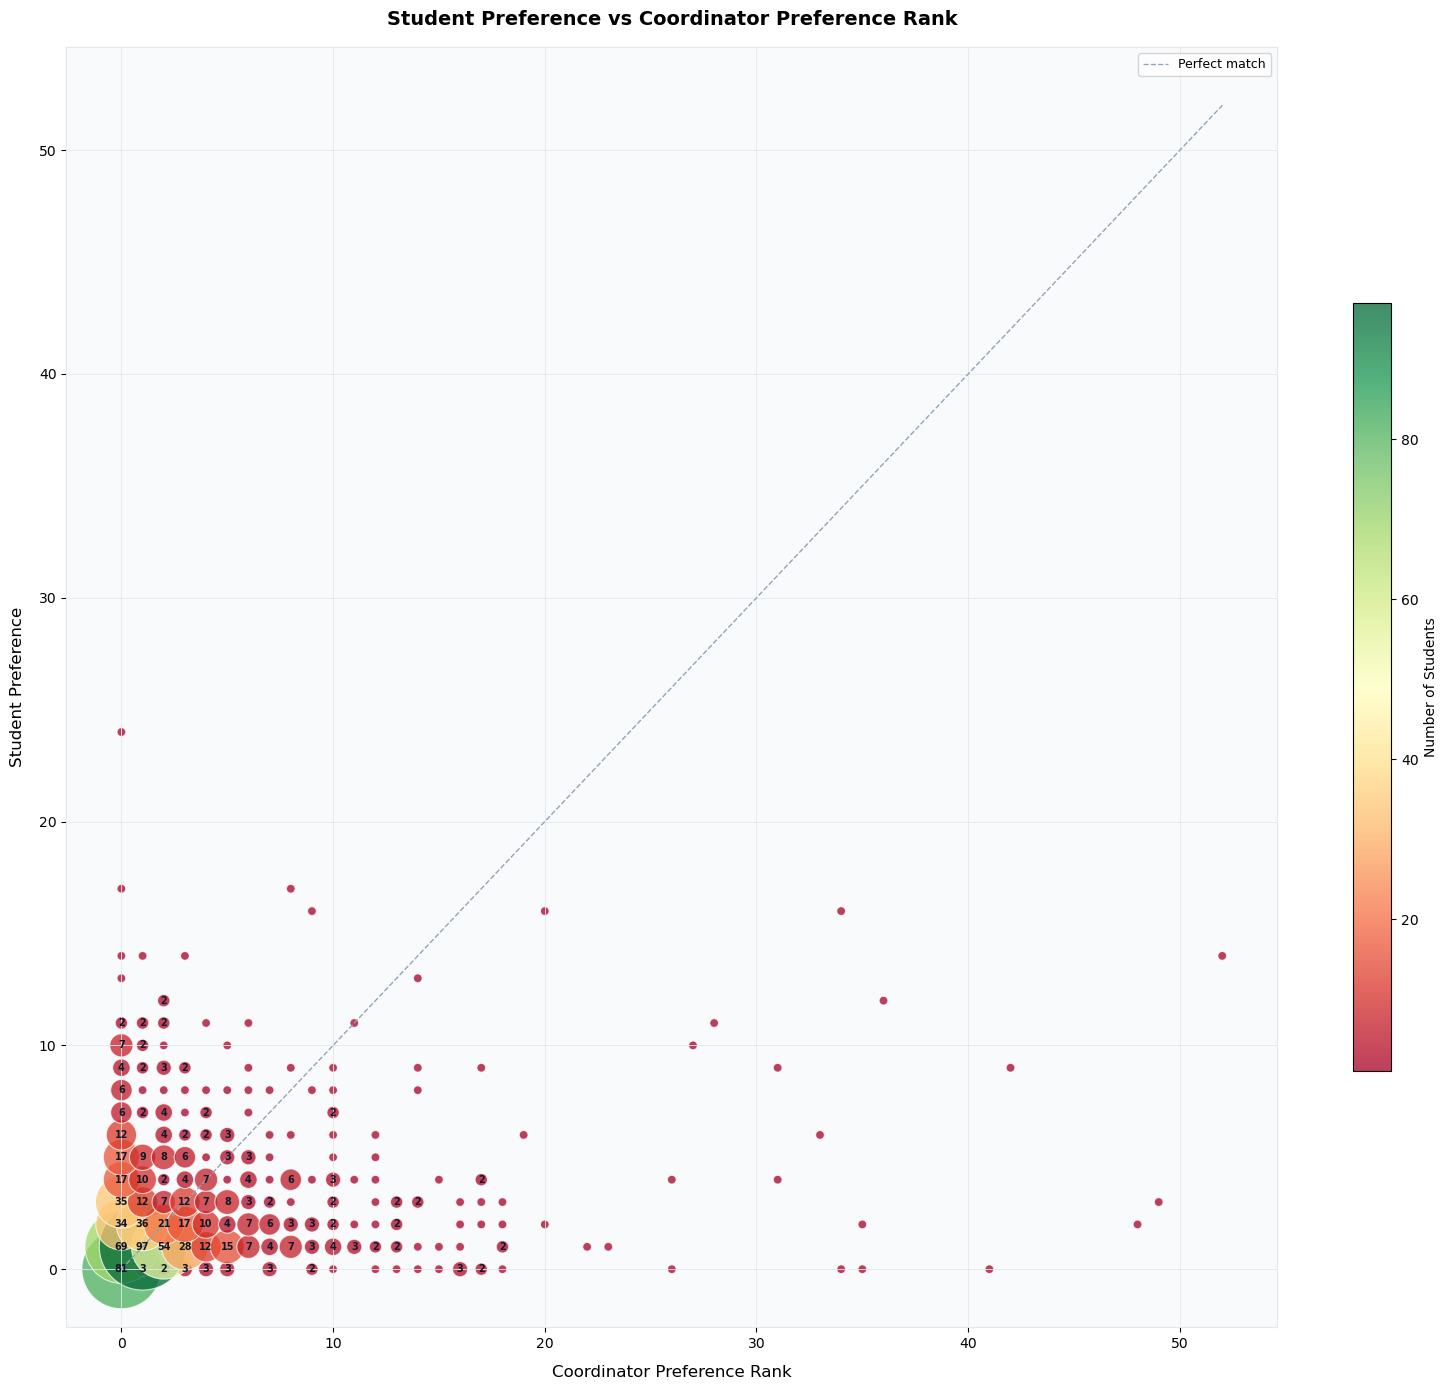

In [59]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

# ── Prep ──────────────────────────────────────────────────────────────────────
placed_df['StudentPreference'] = pd.to_numeric(placed_df['StudentPreference'], errors='coerce').fillna(0).astype(int)
placed_df['Coordinator Preference Rank'] = pd.to_numeric(placed_df['Coordinator Preference Rank'], errors='coerce').fillna(0).astype(int)

hubs = placed_df['Opportunity Campaign Name'].dropna().unique()


# ══════════════════════════════════════════════════════════════
# 1. SMALL MULTIPLES — histogram per hub
# ══════════════════════════════════════════════════════════════
ncols = 2
nrows = int(np.ceil(len(hubs) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5), facecolor='#f5f5f5')
axes = axes.flatten()

bins = range(0, 54)
x = np.arange(0, 53)
width = 0.4




for i, hub in enumerate(sorted(hubs)):
    ax = axes[i]
    hub_df = placed_df[placed_df['Opportunity Campaign Name'] == hub]

    max_rank = max(
    hub_df['StudentPreference'].max(),
    hub_df['Coordinator Preference Rank'].max()
    )

    student_counts, _ = np.histogram(hub_df['StudentPreference'].dropna(), bins=bins)
    coord_counts, _   = np.histogram(hub_df['Coordinator Preference Rank'].dropna(), bins=bins)

    ax.bar(x - width/2, student_counts, width=width, color='#60a5fa', edgecolor='white', label='Student Pref')
    ax.bar(x + width/2, coord_counts,   width=width, color='#4ade80', edgecolor='white', label='Coordinator Rank')

    ax.set_title(hub, fontsize=9, fontweight='bold', pad=6)
    ax.set_xlabel('Rank', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.tick_params(labelsize=10)
    ax.set_facecolor('white')
    ax.set_xlim(-1, max_rank + 1)
    for spine in ax.spines.values():
        spine.set_edgecolor('#e5e7eb')

axes[0].legend(fontsize=8)
for j in range(len(hubs), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Student vs Coordinator Preference Distribution by Hub',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('preference_histograms.png', dpi=150, bbox_inches='tight', facecolor='#f5f5f5')
print("Saved: preference_histograms.png")

# ══════════════════════════════════════════════════════════════
# 2. BUBBLE CHART — Student Rank vs Coordinator Rank
# ══════════════════════════════════════════════════════════════
pivot = placed_df.groupby(
    ['StudentPreference', 'Coordinator Preference Rank']
).size().reset_index(name='count')

# remove 0/NR if you want, or keep for unranked
pivot = pivot[pivot['count'] > 0]

fig2, ax = plt.subplots(figsize=(16, 14), facecolor='white')

scatter = ax.scatter(
    pivot['Coordinator Preference Rank'],
    pivot['StudentPreference'],
    s=pivot['count'] * 40,        # scale bubble size
    c=pivot['count'],
    cmap='RdYlGn',
    alpha=0.75,
    edgecolors='white',
    linewidths=0.8
)

# annotate count inside each bubble
for _, row in pivot.iterrows():
    if row['count'] > 1:
        ax.text(row['Coordinator Preference Rank'], row['StudentPreference'],
                str(int(row['count'])), ha='center', va='center',
                fontsize=7, fontweight='bold', color='#111827')

# diagonal — perfect match line
max_val = max(pivot['StudentPreference'].max(), pivot['Coordinator Preference Rank'].max())
ax.plot([0, max_val], [0, max_val], '--', color='#94a3b8', linewidth=1, label='Perfect match')

plt.colorbar(scatter, ax=ax, label='Number of Students', shrink=0.6)

ax.set_xlabel('Coordinator Preference Rank', fontsize=12, labelpad=10)
ax.set_ylabel('Student Preference', fontsize=12, labelpad=10)
ax.set_title('Student Preference vs Coordinator Preference Rank',
             fontsize=14, fontweight='bold', pad=16)
ax.legend(fontsize=9)
ax.set_facecolor('#f8fafc')
ax.grid(color='#e2e8f0', linewidth=0.6)
for spine in ax.spines.values():
    spine.set_edgecolor('#e2e8f0')

plt.tight_layout()
plt.savefig('preference_bubble.png', dpi=150, bbox_inches='tight')
print("Saved: preference_bubble.png")

In [ ]:

# Single combined chart across all hubs
bins = range(0, 54)
x = np.arange(0, 53)
width = 0.4

max_rank = max(
    placed_df['StudentPreference'].max(),
    placed_df['Coordinator Preference Rank'].max()
)

student_counts, _ = np.histogram(placed_df['StudentPreference'].dropna(), bins=bins)
coord_counts, _   = np.histogram(placed_df['Coordinator Preference Rank'].dropna(), bins=bins)

fig, ax = plt.subplots(figsize=(18, 5), facecolor='#f5f5f5')

ax.bar(x - width/2, student_counts, width=width, color='#60a5fa', edgecolor='white', label='Student Pref')
ax.bar(x + width/2, coord_counts,   width=width, color='#4ade80', edgecolor='white', label='Coordinator Rank')

ax.set_title('Student vs Coordinator Preference Distribution (All Hubs)', fontsize=12, fontweight='bold', pad=8)
ax.set_xlabel('Rank', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_xlim(-1, max_rank + 1)
ax.set_facecolor('white')
ax.legend(fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#e5e7eb')

plt.tight_layout()
plt.savefig('preference_histogram_combined.png', dpi=150, bbox_inches='tight', facecolor='#f5f5f5')
plt.show()
print("Saved: preference_histogram_combined.png")


In [ ]:
import folium

map_df = df_2.dropna(subset=['Postal Address Latitude', 'Postal Address Longitude']).copy()

# Aggregate by location + group name
location_group = map_df.groupby(
    ['Postal Address Latitude', 'Postal Address Longitude', 'Group Name']
)['Student Code'].nunique().reset_index()
location_group.columns = ['lat', 'lon', 'Group Name', 'student_count']

# Assign a color to each unique Group Name (hub)
groups = location_group['Group Name'].unique()
colors = [
    '#4ade80', '#60a5fa', '#f97316', '#a78bfa', '#f472b6',
    '#34d399', '#fbbf24', '#fb7185', '#38bdf8', '#e879f9'
]
color_map = {group: colors[i % len(colors)] for i, group in enumerate(groups)}

m = folium.Map(
    location=[map_df['Postal Address Latitude'].mean(),
              map_df['Postal Address Longitude'].mean()],
    zoom_start=11,
    tiles='CartoDB positron'
)

for _, row in location_group.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=row['student_count'] * 2,  # scale size by student count
        color=color_map[row['Group Name']],
        fill=True,
        fill_color=color_map[row['Group Name']],
        fill_opacity=0.6,
        popup=folium.Popup(
            f"<b>{row['Group Name']}</b><br>Students: {row['student_count']}",
            max_width=200
        )
    ).add_to(m)

# Add legend
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px; border-radius:8px;
     font-family:sans-serif; font-size:12px; box-shadow:2px 2px 6px rgba(0,0,0,0.2)">
  <b>Hubs</b><br>
"""
for group, color in color_map.items():
    legend_html += f'<span style="background:{color};width:12px;height:12px;display:inline-block;border-radius:50%;margin-right:6px"></span>{group}<br>'
legend_html += "</div>"

m.get_root().html.add_child(folium.Element(legend_html))

m.save('student_map.html')
print(f"Total locations plotted: {len(location_group)}")

Total locations plotted: 277


In [57]:


print(summary.to_string())



                                                     Unique Students Matched  Unique Agencies Matched  Accepted Pre Matches  Accepted Bulk Matches  Accepted Manual Matches
Group Name                                                                                                                                                                 
2026 Spring Forward - Community and Social Services                      218                       98                    61                     74                       69
2026 Spring Forward - Healthcare                                         228                       68                    42                    146                       54
2026 Spring Forward - Marketing and Communications                       244                       98                     7                    212                       14
2026 Spring Forward - STEM and Green                                     243                       64                    37                 

In [60]:
# Merge df with df_2 to get Agency Name, then count applications by hub + agency
agency_name_map = df_2[['Agency Id', 'Agency Name']].drop_duplicates()

apps_by_hub_agency = (
    df
    .merge(agency_name_map, on='Agency Id', how='left')
    .groupby(['Opportunity Campaign Name', 'Agency Name'])
    .size()
    .reset_index(name='Applications')
    .sort_values(['Opportunity Campaign Name', 'Applications'], ascending=[True, False])
)

# Show top 10 agencies per hub
top_agencies = apps_by_hub_agency.groupby('Opportunity Campaign Name').head(10)

for hub, group in top_agencies.groupby('Opportunity Campaign Name'):
    print(f"\n{'='*60}")
    print(f"  {hub}")
    print(f"{'='*60}")
    print(group[['Agency Name', 'Applications']].to_string(index=False))


  2026 Spring Forward - Community and Social Services
                                                                  Agency Name  Applications
                                                Center for Justice Innovation           126
                                                      Public Health Solutions           110
                                                       Stand Out College Prep            87
                                              Bridge Philanthropic Consulting            81
                                                 YWCA of the City of New York            79
                                  New York City Department of Social Services            69
                                                    Catskill Animal Sanctuary            56
                                                                Girl Vow Inc.            56
                                                       9/11 Memorial & Museum            53
CUNY Office of Career and

In [61]:

from tabulate import tabulate

# Merge df with df_2 to get Agency Name, then count applications by hub + agency
agency_name_map = df_2[['Agency Id', 'Agency Name']].drop_duplicates()

apps_by_hub_agency = (
    df
    .merge(agency_name_map, on='Agency Id', how='left')
    .groupby(['Opportunity Campaign Name', 'Agency Name'])
    .size()
    .reset_index(name='Applications')
    .sort_values(['Opportunity Campaign Name', 'Applications'], ascending=[True, False])
)

# Top 10 agencies per hub
top_agencies = (
    apps_by_hub_agency
    .groupby('Opportunity Campaign Name')
    .head(10)
    .rename(columns={'Opportunity Campaign Name': 'Hub'})
    .reset_index(drop=True)
)
top_agencies.index += 1

print(tabulate(top_agencies, headers='keys', tablefmt='simple', showindex=False))

Hub                                                  Agency Name                                                                      Applications
---------------------------------------------------  -----------------------------------------------------------------------------  --------------
2026 Spring Forward - Community and Social Services  Center for Justice Innovation                                                             126
2026 Spring Forward - Community and Social Services  Public Health Solutions                                                                   110
2026 Spring Forward - Community and Social Services  Stand Out College Prep                                                                     87
2026 Spring Forward - Community and Social Services  Bridge Philanthropic Consulting                                                            81
2026 Spring Forward - Community and Social Services  YWCA of the City of New York                                     

In [ ]:

# Employer ranking completion by hub
# An employer "completed ranking" if they assigned at least one non-null, non-zero Coordinator Preference Rank

ranked_mask = df['Coordinator Preference Rank'].notna() & (df['Coordinator Preference Rank'] != 0)

total_employers = (
    df.groupby('Opportunity Campaign Name')['Agency Id']
    .nunique()
    .rename('Total Employers')
)

ranked_employers = (
    df[ranked_mask]
    .groupby('Opportunity Campaign Name')['Agency Id']
    .nunique()
    .rename('Employers Who Ranked')
)

employer_ranking_summary = pd.concat([total_employers, ranked_employers], axis=1).fillna(0).astype(int)
employer_ranking_summary['% Completed Ranking'] = (
    employer_ranking_summary['Employers Who Ranked'] / employer_ranking_summary['Total Employers'] * 100
).round(1)

employer_ranking_summary.index = employer_ranking_summary.index.str.replace('2026 Spring Forward - ', '', regex=False)
employer_ranking_summary.index.name = 'Hub'

# Add total row
total_row = pd.DataFrame({
    'Total Employers': [df['Agency Id'].nunique()],
    'Employers Who Ranked': [df[ranked_mask]['Agency Id'].nunique()],
    '% Completed Ranking': [round(df[ranked_mask]['Agency Id'].nunique() / df['Agency Id'].nunique() * 100, 1)]
}, index=pd.Index(['TOTAL'], name='Hub'))

employer_ranking_summary = pd.concat([employer_ranking_summary, total_row])

print(employer_ranking_summary.to_string())


In [ ]:

# Average max rankings employers give, by hub
ranked = df[df['Coordinator Preference Rank'].notna() & (df['Coordinator Preference Rank'] != 0)].copy()

# Max rank given per employer per hub
max_rank_per_employer = (
    ranked.groupby(['Opportunity Campaign Name', 'Agency Id'])['Coordinator Preference Rank']
    .max()
    .reset_index(name='Max Rank Given')
)

avg_max_rank = (
    max_rank_per_employer.groupby('Opportunity Campaign Name')['Max Rank Given']
    .agg(Avg_Max_Rank='mean', Median_Max_Rank='median', Std_Max_Rank='std', Min_Max_Rank='min', Max_Max_Rank='max')
    .round(1)
)

avg_max_rank.index = avg_max_rank.index.str.replace('2026 Spring Forward - ', '', regex=False)
avg_max_rank.index.name = 'Hub'

# Overall
overall = max_rank_per_employer['Max Rank Given'].agg(['mean', 'median', 'std', 'min', 'max']).round(1)
overall_row = pd.DataFrame({
    'Avg_Max_Rank': [overall['mean']],
    'Median_Max_Rank': [overall['median']],
    'Std_Max_Rank': [overall['std']],
    'Min_Max_Rank': [overall['min']],
    'Max_Max_Rank': [overall['max']]
}, index=pd.Index(['TOTAL'], name='Hub'))

print(pd.concat([avg_max_rank, overall_row]).to_string())
